In [1]:
# Cell 1
from pathlib import Path
import ast
import math

import numpy as np
import pandas as pd
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

In [2]:
# Cell 2
DATA_DIR = Path("../data")
metadata_df = pd.read_parquet(DATA_DIR  / "movies.parquet")   # change filename if needed
metadata_df.head()

,id,title,rating,vote_count,genre_ids,keyword_ids,poster_local,year
0,11688,The Emperor's New Groove,7.558,7184,"[12, 16, 35, 10751, 14]","[1291, 4152, 1421, 5967, 2280, 3289, 3998, 936...",posters/11688.jpg,2000
1,9741,Unbreakable,7.142,9781,"[53, 18, 9648]","[276, 970, 5809, 9715, 4619, 8872, 15208, 3363...",posters/9741.jpg,2000
2,10867,Malena,7.427,2452,[18],"[931, 629, 4129, 1956, 4115, 9767, 9986, 15049...",posters/10867.jpg,2000
3,107,Snatch,7.817,9776,"[80, 35]","[642, 900, 392, 394, 395, 397, 398, 1385, 4931...",posters/107.jpg,2000
4,22705,Cheeky,5.605,281,"[35, 18, 10749]","[596, 924, 3182, 180340, 190370, 211121]",posters/22705.jpg,2000


In [3]:
# Metadata prep / restricted genre extraction

GENRE_MAP = {
    28: "Action", 12: "Adventure", 16: "Animation", 35: "Comedy",
    80: "Crime", 99: "Documentary", 18: "Drama", 10751: "Family",
    14: "Fantasy", 36: "History", 27: "Horror", 10402: "Music",
    9648: "Mystery", 10749: "Romance", 878: "SciFi", 10770: "TVMovie",
    53: "Thriller", 10752: "War", 37: "Western"
}

# Priority order for target genres
TARGET_GENRES = {
    28: "Action",
    16: "Animation",
    35: "Comedy",
    18: "Drama",
    27: "Horror",
}
TARGET_PRIORITY = [28, 16, 35, 18, 27]

def parse_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if x is None:
        return []
    if isinstance(x, float) and pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if x == "" or x == "[]":
            return []
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, np.ndarray):
                return parsed.tolist()
            if isinstance(parsed, tuple):
                return list(parsed)
            if isinstance(parsed, list):
                return parsed
            return []
        except Exception:
            return []
    return []

def pick_priority_genre(genre_ids):
    genre_ids = [int(g) for g in genre_ids]
    for gid in TARGET_PRIORITY:
        if gid in genre_ids:
            return gid
    return None

df = metadata_df.copy()
df = df[df["poster_local"].notna()].copy()
df["poster_local"] = df["poster_local"].astype(str).str.strip()
df = df[df["poster_local"] != ""].copy()

# Parse genres
df["genre_list"] = df["genre_ids"].apply(parse_list)

# Pick one genre only from the allowed target set, by priority
df["genre_id"] = df["genre_list"].apply(pick_priority_genre)
df["genre"] = df["genre_id"].map(TARGET_GENRES)

# Drop movies that do not match any of the target genres
df = df[df["genre"].notna()].copy()

# Poster path
df["full_path"] = df["poster_local"].apply(lambda p: DATA_DIR / p)
df = df[df["full_path"].apply(lambda p: p.exists())].copy()

print(df[["genre_ids", "genre_list", "genre_id", "genre"]].head(10))
print()
print(df["genre"].value_counts())
display(df[["title", "poster_local", "genre"]].head())

Empty DataFrame
Columns: [genre_ids, genre_list, genre_id, genre]
Index: []

Series([], Name: count, dtype: int64)


,title,poster_local,genre


In [4]:
# Cell: simple feature extractor

def load_rgb(path, max_side=512):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    scale = min(1.0, max_side / max(w, h))
    if scale < 1.0:
        img = img.resize((int(w * scale), int(h * scale)), Image.Resampling.LANCZOS)
    return np.array(img)

def extract_features(path):
    rgb = load_rgb(path)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

    brightness = gray.mean() / 255.0
    contrast = gray.std() / 255.0
    saturation = hsv[..., 1].mean() / 255.0

    hue = hsv[..., 0]
    warm_ratio = np.mean((hue <= 20) | (hue >= 160))
    cool_ratio = np.mean((hue >= 80) & (hue <= 140))
    warmth_score = warm_ratio - cool_ratio

    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)

    h, w = gray.shape
    mid = w // 2
    left = gray[:, :mid].astype(float)
    right = np.fliplr(gray[:, w - mid:]).astype(float)
    symmetry_score = 1.0 - np.mean(np.abs(left - right)) / 255.0

    lap = np.abs(cv2.Laplacian(gray, cv2.CV_32F))
    ys, xs = np.indices(gray.shape)
    total = lap.sum() + 1e-9
    visual_center_x = ((xs * lap).sum() / total) / w
    visual_center_y = ((ys * lap).sum() / total) / h

    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    gx = cv2.Sobel(blur, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(blur, cv2.CV_32F, 0, 1, ksize=3)
    grad = cv2.magnitude(gx, gy)
    thr = np.percentile(grad, 60)
    negative_space_ratio = np.mean(grad <= thr)

    return {
        "brightness": float(brightness),
        "contrast": float(contrast),
        "saturation": float(saturation),
        "warmth_score": float(warmth_score),
        "edge_density": float(edge_density),
        "symmetry_score": float(symmetry_score),
        "visual_center_x": float(visual_center_x),
        "visual_center_y": float(visual_center_y),
        "negative_space_ratio": float(negative_space_ratio),
    }

In [10]:
# Cell: extract features for all posters

rows = []

for i, row in enumerate(df.itertuples(index=False), 1):
    try:
        feats = extract_features(row.full_path)
        feats["poster_local"] = row.poster_local
        rows.append(feats)
    except Exception:
        pass

    if i % 1000 == 0:
        print(f"{i}/{len(df)}")

df_features = pd.DataFrame(rows)
print(df_features.shape)
df_features.head()

(0, 0)


""


In [11]:
# # Cell: merge metadata + features

df2 = df.merge(df_features, on="poster_local", how="inner").copy()

feature_cols = [
    "brightness",
    "contrast",
    "saturation",
    "warmth_score",
    "edge_density",
    "symmetry_score",
    "visual_center_x",
    "visual_center_y",
    "negative_space_ratio",
]

print(df2.shape)
df2[["title", "genre"] + feature_cols].head()

KeyError: 'poster_local'

In [ ]:
# # Wider feature set: image features + metadata

df2["num_genres"] = df2["genre_list"].apply(len)
df2["num_keywords"] = df2["keyword_ids"].apply(lambda x: len(parse_list(x)))

df2["log_vote_count"] = np.log1p(df2["vote_count"])

df2["title_len"] = df2["title"].astype(str).str.len()
df2["title_word_count"] = df2["title"].astype(str).apply(lambda s: len(s.split()))

feature_cols = [
    # image features
    "brightness",
    "contrast",
    "saturation",
    "warmth_score",
    "edge_density",
    "symmetry_score",
    "visual_center_x",
    "visual_center_y",
    "negative_space_ratio",

    # metadata features
    "year",
    "rating",
    "vote_count",
    "log_vote_count",
    "num_genres",
    "num_keywords",
    "title_len",
    "title_word_count",
]

feature_cols = [
    c for c in feature_cols
    if c in df2.columns and df2[c].notna().sum() >= len(df2)*0.8 and df2[c].nunique() >= 5
]

print("Using features:")
print(feature_cols)

In [ ]:
# Cell 6 — BIGGER feature set: image + engineered metadata + top keyword indicators
from collections import Counter

# ---------- engineered image features ----------
df2["center_distance"] = np.sqrt((df2["visual_center_x"] - 0.5)**2 + (df2["visual_center_y"] - 0.5)**2)
df2["darkness"] = 1.0 - df2["brightness"]
df2["color_contrast_combo"] = df2["contrast"] * df2["saturation"]
df2["warm_bright_combo"] = df2["warmth_score"] * df2["brightness"]
df2["symmetry_edge_combo"] = df2["symmetry_score"] * df2["edge_density"]

# ---------- engineered metadata features ----------
df2["genre_list_len"] = df2["genre_list"].apply(len)

df2["keyword_list"] = df2["keyword_ids"].apply(parse_list)
df2["num_keywords"] = df2["keyword_list"].apply(len)

df2["log_vote_count"] = np.log1p(df2["vote_count"])
df2["log_rating_votes"] = df2["rating"] * df2["log_vote_count"]

df2["decade"] = (df2["year"] // 10) * 10
df2["movie_age"] = df2["year"].max() - df2["year"]

title_series = df2["title"].astype(str)
df2["title_len"] = title_series.str.len()
df2["title_word_count"] = title_series.str.split().str.len()
df2["avg_title_word_len"] = df2["title_len"] / df2["title_word_count"].replace(0, np.nan)

df2["title_has_colon"] = title_series.str.contains(":").astype(int)
df2["title_has_question"] = title_series.str.contains(r"\?").astype(int)
df2["title_has_exclamation"] = title_series.str.contains("!").astype(int)
df2["title_has_number"] = title_series.str.contains(r"\d").astype(int)

# ---------- choose common keywords as binary BN nodes ----------
kw_counter = Counter()
for kws in df2["keyword_list"]:
    kw_counter.update(kws)

TOP_KW = 40
MIN_KW_COUNT = 40

top_keywords = [
    kw for kw, cnt in kw_counter.most_common()
    if cnt >= MIN_KW_COUNT
][:TOP_KW]

for kw in top_keywords:
    df2[f"kw_{kw}"] = df2["keyword_list"].apply(lambda xs: int(kw in xs))

keyword_bin_cols = [f"kw_{kw}" for kw in top_keywords]

# ---------- numeric feature list ----------
feature_cols = [
    # base image features
    "brightness",
    "contrast",
    "saturation",
    "warmth_score",
    "edge_density",
    "symmetry_score",
    "visual_center_x",
    "visual_center_y",
    "negative_space_ratio",

    # derived image features
    "center_distance",
    "darkness",
    "color_contrast_combo",
    "warm_bright_combo",
    "symmetry_edge_combo",

    # metadata
    "year",
    "decade",
    "movie_age",
    "rating",
    "vote_count",
    "log_vote_count",
    "log_rating_votes",
    "genre_list_len",
    "num_keywords",
    "title_len",
    "title_word_count",
    "avg_title_word_len",
]

feature_cols = [
    c for c in feature_cols
    if c in df2.columns and df2[c].notna().sum() >= len(df2) * 0.8 and df2[c].nunique() >= 5
]

print("Numeric features:")
print(feature_cols)
print()
print("Keyword indicator features:")
print(keyword_bin_cols[:20], "..." if len(keyword_bin_cols) > 20 else "")
print(f"Total keyword nodes: {len(keyword_bin_cols)}")

NameError: name 'df2' is not defined

In [ ]:
df2 = df2[df2['vote_count'] >= 50]
len(df2)

9422

In [ ]:
# # Cell: discretize features for the Bayesian Network

# for col in feature_cols:
#     df2[col + "_bin"] = pd.qcut(
#         df2[col],
#         q=3,
#         labels=["low", "mid", "high"],
#         duplicates="drop"
#     )

# bin_cols = [c + "_bin" for c in feature_cols]
# bn_df = df2[["genre"] + bin_cols].dropna().copy()

# print(bn_df.shape)
# bn_df.head()

In [ ]:
# # Discretize features for the Bayesian Network

# for col in feature_cols:
#     df2[col + "_bin"] = pd.qcut(
#         df2[col],
#         q=3,
#         labels=["low", "mid", "high"],
#         duplicates="drop"
#     )

# bin_cols = [c + "_bin" for c in feature_cols if c + "_bin" in df2.columns]

# bn_df = df2[["genre"] + bin_cols].dropna().copy()

# print("BN dataframe shape:", bn_df.shape)
# print("Number of BN feature nodes:", len(bin_cols))

# bn_df.head()

In [ ]:
# Cell 7 — discretize numeric features, keep keyword indicators as-is, build BN dataframe

for col in feature_cols:
    df2[col + "_bin"] = pd.qcut(
        df2[col],
        q=3,
        labels=["low", "mid", "high"],
        duplicates="drop"
    )

numeric_bin_cols = [c + "_bin" for c in feature_cols if c + "_bin" in df2.columns]

for col in keyword_bin_cols:
    df2[col] = df2[col].map({0: "absent", 1: "present"})

bin_cols = numeric_bin_cols + keyword_bin_cols

bn_df = df2[["genre"] + bin_cols].dropna().copy()

print("BN dataframe shape:", bn_df.shape)
print("Number of numeric BN nodes:", len(numeric_bin_cols))
print("Number of keyword BN nodes:", len(keyword_bin_cols))
print("Total BN feature nodes:", len(bin_cols))

bn_df.head()

BN dataframe shape: (9422, 66)
Number of numeric BN nodes: 25
Number of keyword BN nodes: 40
Total BN feature nodes: 65


,genre,brightness_bin,contrast_bin,saturation_bin,warmth_score_bin,edge_density_bin,symmetry_score_bin,visual_center_x_bin,visual_center_y_bin,negative_space_ratio_bin,...,kw_212,kw_12670,kw_258533,kw_10714,kw_3289,kw_325761,kw_1930,kw_2343,kw_6149,kw_233
2,Drama,high,low,low,mid,low,mid,high,mid,high,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
4,Animation,high,low,mid,mid,high,mid,mid,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
5,Drama,low,high,mid,mid,mid,low,low,high,mid,...,absent,present,absent,absent,absent,absent,absent,absent,absent,absent
7,Action,mid,high,mid,high,low,high,mid,mid,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
8,Action,low,high,high,low,mid,high,low,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent


In [ ]:
# Cell: train/test split

train_df, test_df = train_test_split(
    bn_df,
    test_size=0.25,
    random_state=42,
    stratify=bn_df["genre"]
)

print(train_df.shape, test_df.shape)

(7066, 66) (2356, 66)


In [ ]:
# Cell: train the Bayesian Network

edges = [("genre", col) for col in bin_cols]

model = DiscreteBayesianNetwork(edges)
model.fit(train_df, estimator=BayesianEstimator, prior_type="BDeu")

print("Valid model:", model.check_model())
print("Edges:", edges)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'genre': 'C', 'brightness_bin': 'O', 'contrast_bin': 'O', 'saturation_bin': 'O', 'warmth_score_bin': 'O', 'edge_density_bin': 'O', 'symmetry_score_bin': 'O', 'visual_center_x_bin': 'O', 'visual_center_y_bin': 'O', 'negative_space_ratio_bin': 'O', 'center_distance_bin': 'O', 'darkness_bin': 'O', 'color_contrast_combo_bin': 'O', 'warm_bright_combo_bin': 'O', 'symmetry_edge_combo_bin': 'O', 'year_bin': 'O', 'movie_age_bin': 'O', 'rating_bin': 'O', 'vote_count_bin': 'O', 'log_vote_count_bin': 'O', 'log_rating_votes_bin': 'O', 'genre_list_len_bin': 'O', 'num_keywords_bin': 'O', 'title_len_bin': 'O', 'title_word_count_bin': 'O', 'avg_title_word_len_bin': 'O', 'kw_818': 'C', 'kw_187056': 'C', 'kw_9672': 'C', 'kw_179431': 'C', 'kw_9663': 'C', 'kw_9826': 'C', 'kw_210024': 'C', 'kw_9748': 'C', 'kw_6054': 'C', 'kw_179430': 'C', 'kw_5565': 'C', 'kw_9714': 'C', 'kw_242': 'C', 'kw_9717': 'C', 'k

Valid model: True
Edges: [('genre', 'brightness_bin'), ('genre', 'contrast_bin'), ('genre', 'saturation_bin'), ('genre', 'warmth_score_bin'), ('genre', 'edge_density_bin'), ('genre', 'symmetry_score_bin'), ('genre', 'visual_center_x_bin'), ('genre', 'visual_center_y_bin'), ('genre', 'negative_space_ratio_bin'), ('genre', 'center_distance_bin'), ('genre', 'darkness_bin'), ('genre', 'color_contrast_combo_bin'), ('genre', 'warm_bright_combo_bin'), ('genre', 'symmetry_edge_combo_bin'), ('genre', 'year_bin'), ('genre', 'movie_age_bin'), ('genre', 'rating_bin'), ('genre', 'vote_count_bin'), ('genre', 'log_vote_count_bin'), ('genre', 'log_rating_votes_bin'), ('genre', 'genre_list_len_bin'), ('genre', 'num_keywords_bin'), ('genre', 'title_len_bin'), ('genre', 'title_word_count_bin'), ('genre', 'avg_title_word_len_bin'), ('genre', 'kw_818'), ('genre', 'kw_187056'), ('genre', 'kw_9672'), ('genre', 'kw_179431'), ('genre', 'kw_9663'), ('genre', 'kw_9826'), ('genre', 'kw_210024'), ('genre', 'kw_974

In [ ]:
# Cell: predict on test set

infer = VariableElimination(model)

predictions = []
truth = []

for row in test_df.itertuples(index=False):
    evidence = {col: getattr(row, col) for col in bin_cols}
    q = infer.query(variables=["genre"], evidence=evidence, show_progress=False)
    pred = q.state_names["genre"][q.values.argmax()]
    predictions.append(pred)
    truth.append(row.genre)

acc = accuracy_score(truth, predictions)
print("Test accuracy:", acc)
print()
print(classification_report(truth, predictions))

Test accuracy: 0.5390492359932089

              precision    recall  f1-score   support

      Action       0.59      0.53      0.56       644
   Animation       0.52      0.70      0.60       191
      Comedy       0.52      0.55      0.53       618
       Drama       0.59      0.49      0.53       701
      Horror       0.39      0.56      0.46       202

    accuracy                           0.54      2356
   macro avg       0.52      0.56      0.54      2356
weighted avg       0.55      0.54      0.54      2356



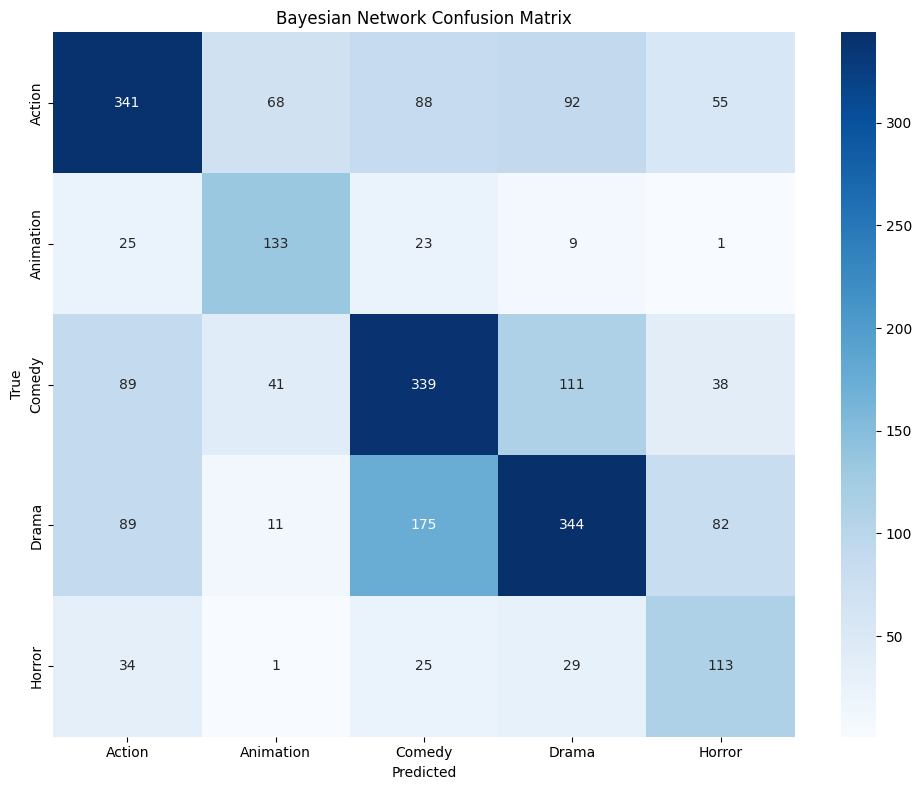

In [ ]:
# Cell: color confusion matrix

labels = sorted(set(truth))
cm = confusion_matrix(truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Bayesian Network Confusion Matrix")
plt.tight_layout()
plt.show()

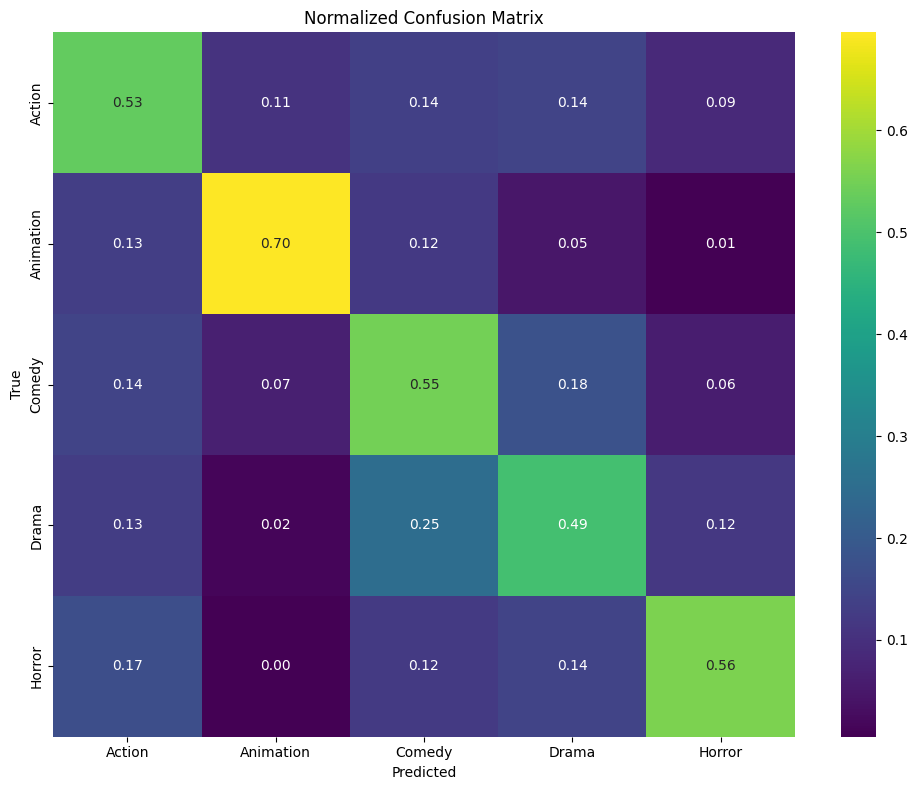

In [ ]:
# Cell: normalized confusion matrix

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Cell: compare to majority-class baseline

majority = train_df["genre"].value_counts().idxmax()
baseline_preds = [majority] * len(test_df)

print("Majority genre:", majority)
print("Baseline accuracy:", accuracy_score(test_df["genre"], baseline_preds))
print("BN accuracy:", acc)

Majority genre: Drama
Baseline accuracy: 0.2975382003395586
BN accuracy: 0.5390492359932089


In [ ]:
import pickle

MODEL_PATH = "../data/poster_genre_bn.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model, f)

print("Model saved to", MODEL_PATH)

Model saved to poster_genre_bn.pkl
